# Melbourne Housing Price Predictor
## A Multivariate Linear Regression Analysis

This notebook predicts Melbourne housing prices using linear regression.
The dataset is sourced from Kaggle (Tony Pino) and contains Melbourne 
housing market data from January 2016.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('Melbourne_housing_FULL.csv')

In [3]:
# Display the first few rows
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (34857, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [4]:
# Check column names and data types
print("Column Names and Data Types:")
print(df.dtypes)

Column Names and Data Types:
Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object


In [5]:
print(f"\nTotal Missing Values per Column:")
print(df.isnull().sum())


Total Missing Values per Column:
Suburb               0
Address              0
Rooms                0
Type                 0
Price             7610
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom2          8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21115
YearBuilt        19306
CouncilArea          3
Lattitude         7976
Longtitude        7976
Regionname           3
Propertycount        3
dtype: int64


In [6]:
# Drop rows where Price is missing (our target variable)
df = df.dropna(subset=['Price'])
print(f"Rows after dropping missing Price: {len(df)}") 

Rows after dropping missing Price: 27247


In [7]:
# Drop columns with too many missing values
df = df.drop(columns=['BuildingArea', 'YearBuilt'])

In [8]:
# Fill remaining numerical missing values with median
df['Bedroom2'] = df['Bedroom2'].fillna(df['Bedroom2'].median())
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())
df['Car'] = df['Car'].fillna(df['Car'].median())
df['Landsize'] = df['Landsize'].fillna(df['Landsize'].median())
df['Lattitude'] = df['Lattitude'].fillna(df['Lattitude'].median())
df['Longtitude'] = df['Longtitude'].fillna(df['Longtitude'].median())
df['Distance'] = df['Distance'].fillna(df['Distance'].median())
df['Postcode'] = df['Postcode'].fillna(df['Postcode'].median())

In [9]:
# Verify no missing values remain in numerical columns
print(f"\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
CouncilArea      3
Lattitude        0
Longtitude       0
Regionname       3
Propertycount    3
dtype: int64


In [10]:
# Drop remaining rows with missing values (only 3 rows, safe to drop)
df = df.dropna(subset=['CouncilArea', 'Regionname', 'Propertycount'])

In [11]:
print(f"\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64


In [12]:
print(df.shape)

(27244, 19)


In [13]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,Propertycount
count,27244.000000,2.724400e+04,27244.000000,27244.000000,27244.000000,27244.000000,27244.000000,27244.000000,27244.000000,27244.000000,27244.000000
mean,2.992365,1.050210e+06,11.280634,3113.799479,3.035311,1.451732,1.786632,565.785567,-37.805471,144.998200,7566.781089
std,0.954810,6.414923e+05,6.787580,111.141993,0.834902,0.662012,0.869588,3052.714373,0.080471,0.105969,4492.382418
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,-38.190430,144.423790,83.000000
25%,2.000000,6.350000e+05,6.400000,3046.000000,3.000000,1.000000,1.000000,351.000000,-37.842848,144.954300,4294.000000
50%,3.000000,8.700000e+05,10.500000,3088.000000,3.000000,1.000000,2.000000,512.000000,-37.800460,145.003200,6567.000000
75%,4.000000,1.295000e+06,14.000000,3153.000000,3.000000,2.000000,2.000000,592.000000,-37.766000,145.048360,10412.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,20.000000,9.000000,18.000000,433014.000000,-37.397800,145.526350,21650.000000


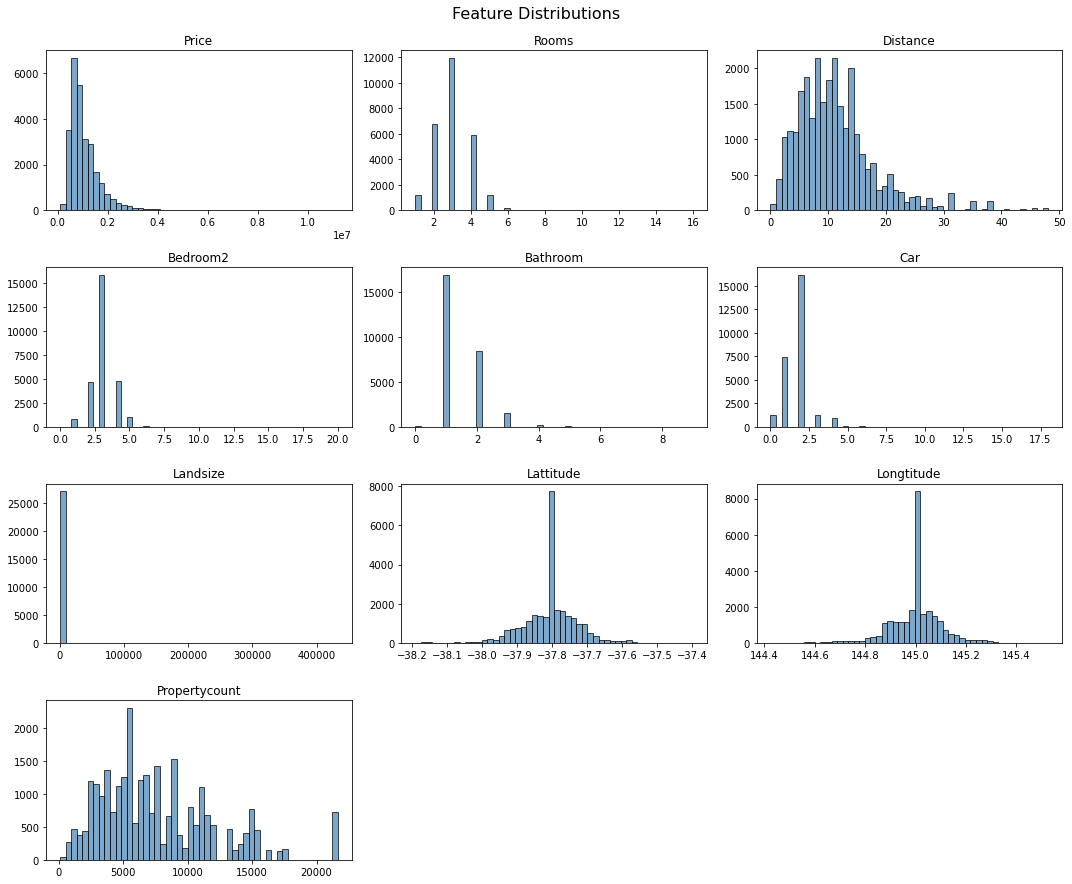

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

# Plot histograms for all numerical columns
numerical_cols = ['Price', 'Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Propertycount']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i+1)
    plt.hist(df[col], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    plt.title(col)
    plt.tight_layout()

plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

In [15]:
# Remove outliers
print(f"Shape before removing outliers: {df.shape}")

Shape before removing outliers: (27244, 19)


In [16]:
# Remove extreme prices (keep between $100k and $3M - realistic Melbourne prices)
df = df[df['Price'] <= 3000000]
df = df[df['Price'] >= 100000]

In [17]:
# Remove unrealistic land sizes (keep below 10,000 sqm - realistic for Melbourne)
df = df[df['Landsize'] <= 10000]

In [18]:
# Remove unrealistic bedroom/room counts
df = df[df['Bedroom2'] <= 10]
df = df[df['Rooms'] <= 10]
df = df[df['Car'] <= 10]

In [19]:
print(f"Shape after removing outliers: {df.shape}")
print(f"\nRows removed: {27244 - len(df)}")

Shape after removing outliers: (26757, 19)

Rows removed: 487


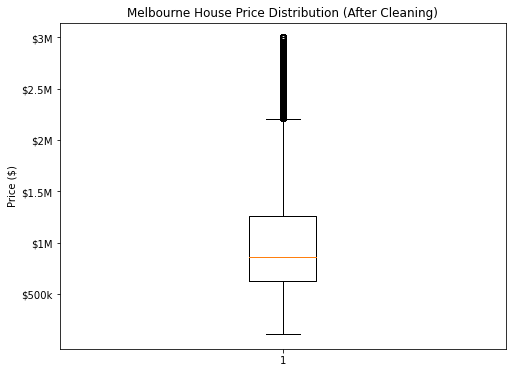

In [20]:
# Box plot for Price
plt.figure(figsize=(8, 6))
plt.boxplot(df['Price'], vert=True)
plt.title('Melbourne House Price Distribution (After Cleaning)')
plt.ylabel('Price ($)')
plt.yticks([500000, 1000000, 1500000, 2000000, 2500000, 3000000],
           ['$500k', '$1M', '$1.5M', '$2M', '$2.5M', '$3M'])
plt.savefig('price_boxplot.png', bbox_inches='tight')
plt.show()

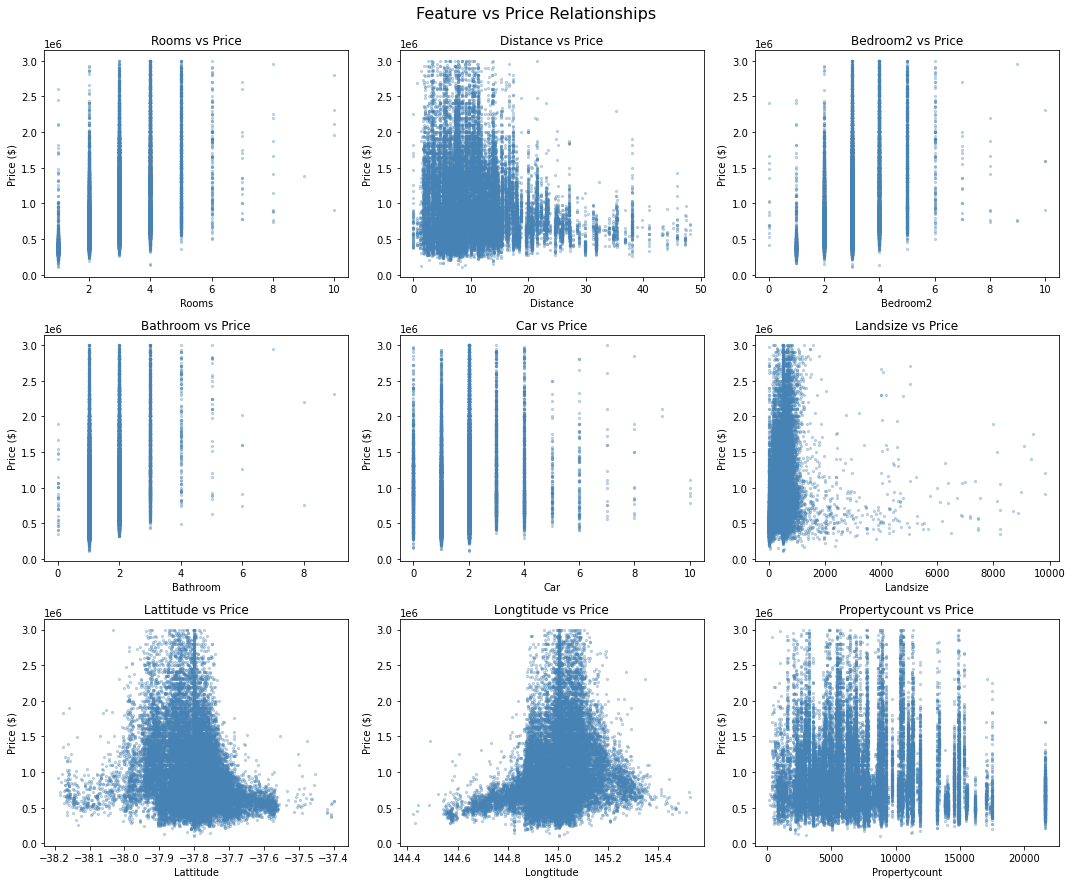

In [21]:
# Scatter plots of each feature vs Price
numerical_cols = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Propertycount']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i+1)
    plt.scatter(df[col], df['Price'], alpha=0.3, color='steelblue', s=5)
    plt.xlabel(col)
    plt.ylabel('Price ($)')
    plt.title(f'{col} vs Price')
    plt.tight_layout()

plt.suptitle('Feature vs Price Relationships', fontsize=16, y=1.02)
plt.savefig('scatter_plots.png', bbox_inches='tight')
plt.show()

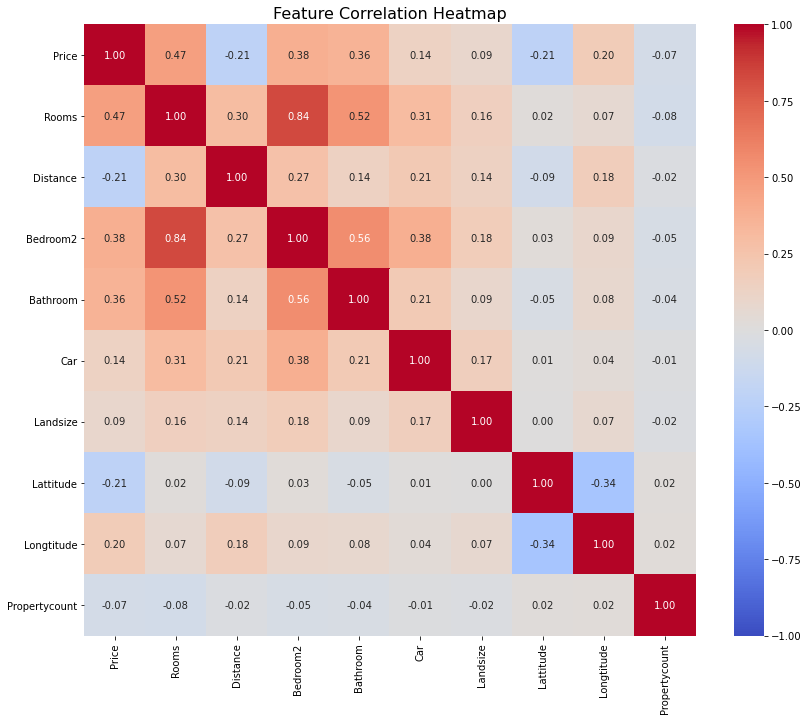

In [22]:
# Correlation heatmap
plt.figure(figsize=(12, 10))

# Calculate correlation
numerical_df = df[['Price', 'Rooms', 'Distance', 'Bedroom2', 
                    'Bathroom', 'Car', 'Landsize', 'Lattitude', 
                    'Longtitude', 'Propertycount']]
corr = numerical_df.corr()

# Plot heatmap
sns.heatmap(corr, 
            annot=True,          # Show numbers in each cell
            fmt='.2f',           # Round to 2 decimal places
            cmap='coolwarm',     # Red/blue colour scheme
            vmin=-1, vmax=1,     # Scale from -1 to 1
            center=0,
            square=True)

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────
# FEATURE ENGINEERING
# One-hot encode Type and Regionname
# ─────────────────────────────────────────

df_enc = pd.get_dummies(df, columns=['Type', 'Regionname'], drop_first=True)

new_cols = [c for c in df_enc.columns if c.startswith('Type_') or c.startswith('Regionname_')]
print("New encoded columns created:")
for col in new_cols:
    print(f"  {col}")

print(f"\nDataset shape after encoding: {df_enc.shape}")

New encoded columns created:
  Type_t
  Type_u
  Regionname_Eastern Victoria
  Regionname_Northern Metropolitan
  Regionname_Northern Victoria
  Regionname_South-Eastern Metropolitan
  Regionname_Southern Metropolitan
  Regionname_Western Metropolitan
  Regionname_Western Victoria

Dataset shape after encoding: (26757, 26)


In [30]:
# ─────────────────────────────────────────
# DEFINE FEATURES
# ─────────────────────────────────────────

features = ['Rooms', 'Distance', 'Bathroom', 'Car', 
            'Lattitude', 'Longtitude',
            'Bedroom2', 'Landsize', 'Propertycount',
            'Type_t', 'Type_u',
            'Regionname_Northern Metropolitan',
            'Regionname_South-Eastern Metropolitan',
            'Regionname_Southern Metropolitan',
            'Regionname_Western Metropolitan',
            'Regionname_Eastern Victoria',
            'Regionname_Northern Victoria',
            'Regionname_Western Victoria']

# Keep only features that actually exist after encoding
features = [f for f in features if f in df_enc.columns]

X = df_enc[features]
y_raw = df['Price']           # original price
y_log = np.log(df['Price'])   # log-transformed price

print(f"Features used: {len(features)}")
print(f"X shape: {X.shape}")
print(f"\nFeature list:")
for f in features:
    print(f"  {f}")

Features used: 18
X shape: (26757, 18)

Feature list:
  Rooms
  Distance
  Bathroom
  Car
  Lattitude
  Longtitude
  Bedroom2
  Landsize
  Propertycount
  Type_t
  Type_u
  Regionname_Northern Metropolitan
  Regionname_South-Eastern Metropolitan
  Regionname_Southern Metropolitan
  Regionname_Western Metropolitan
  Regionname_Eastern Victoria
  Regionname_Northern Victoria
  Regionname_Western Victoria


In [31]:
# ─────────────────────────────────────────
# TRAIN/TEST SPLIT + FEATURE SCALING
# ─────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log,          # using log-transformed price
    test_size=0.2,
    random_state=42
)

# Keep a raw price version for final evaluation (so RMSE is in dollars)
_, _, y_train_raw, y_test_raw = train_test_split(
    X, y_raw,
    test_size=0.2,
    random_state=42    # same seed = same split
)

# Scale features — StandardScaler makes mean=0, std=1
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # apply same scale to test

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"\nWhy log-transform price?")
print(f"  Original price mean:  ${y_raw.mean():,.0f}")
print(f"  Original price std:   ${y_raw.std():,.0f}")
print(f"  Log price mean:       {y_log.mean():.3f}")
print(f"  Log price std:        {y_log.std():.3f}")
print(f"\nWhy scale features?")
print(f"  Distance range before scaling: {X_train['Distance'].min():.1f} to {X_train['Distance'].max():.1f}")
print(f"  Distance range after scaling:  {X_train_sc[:,1].min():.2f} to {X_train_sc[:,1].max():.2f}")

Training set:  (21405, 18)
Test set:      (5352, 18)

Why log-transform price?
  Original price mean:  $1,002,446
  Original price std:   $513,034
  Log price mean:       13.699
  Log price std:        0.486

Why scale features?
  Distance range before scaling: 0.0 to 48.1
  Distance range after scaling:  -1.66 to 5.39


In [32]:
# ─────────────────────────────────────────
# MODEL 1: Original Linear Regression
# ─────────────────────────────────────────

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

features_v1 = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Lattitude', 'Longtitude']

X_v1 = df[features_v1]
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(X_v1, y_raw, test_size=0.2, random_state=42)

sc1 = StandardScaler()
lr  = LinearRegression()
lr.fit(sc1.fit_transform(X_tr1), y_tr1)

p1      = lr.predict(sc1.transform(X_te1))
r2_v1   = r2_score(y_te1, p1)
rmse_v1 = np.sqrt(mean_squared_error(y_te1, p1))

print(f"Model 1 — Linear Regression (original baseline)")
print(f"  Features:  {len(features_v1)}")
print(f"  R² Score:  {r2_v1:.4f}")
print(f"  RMSE:      ${rmse_v1:,.0f}")

Model 1 — Linear Regression (original baseline)
  Features:  6
  R² Score:  0.4671
  RMSE:      $374,846


In [33]:
# ─────────────────────────────────────────
# MODEL 2: Ridge Regression
# ─────────────────────────────────────────

from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)

p2_log  = ridge.predict(X_test_sc)
p2      = np.exp(p2_log)        # convert log predictions back to dollars
r2_v2   = r2_score(y_test_raw, p2)
rmse_v2 = np.sqrt(mean_squared_error(y_test_raw, p2))

print(f"Model 2 — Ridge Regression (improved)")
print(f"  Features:  {len(features)}")
print(f"  R² Score:  {r2_v2:.4f}")
print(f"  RMSE:      ${rmse_v2:,.0f}")
print(f"\n  Gain over Model 1:")
print(f"  R² +{(r2_v2 - r2_v1)*100:.1f} pts   RMSE -${rmse_v1 - rmse_v2:,.0f}")

Model 2 — Ridge Regression (improved)
  Features:  18
  R² Score:  0.6266
  RMSE:      $313,779

  Gain over Model 1:
  R² +15.9 pts   RMSE -$61,068


In [34]:
# ─────────────────────────────────────────
# MODEL 3: Gradient Boosting
# Captures non-linear relationships linear models can't
# ─────────────────────────────────────────

from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,   # number of trees built
    max_depth=5,        # depth of each tree
    learning_rate=0.1,  # alpha — step size from your lecture
    subsample=0.8,      # use 80% of data per tree
    random_state=42
)

gb.fit(X_train, y_train)

p3_log  = gb.predict(X_test)
p3      = np.exp(p3_log)
r2_v3   = r2_score(y_test_raw, p3)
rmse_v3 = np.sqrt(mean_squared_error(y_test_raw, p3))

print(f"Model 3 — Gradient Boosting (best)")
print(f"  Features:  {len(features)}")
print(f"  R² Score:  {r2_v3:.4f}")
print(f"  RMSE:      ${rmse_v3:,.0f}")
print(f"\n  Gain over Model 1:")
print(f"  R² +{(r2_v3 - r2_v1)*100:.1f} pts   RMSE -${rmse_v1 - rmse_v3:,.0f}")

Model 3 — Gradient Boosting (best)
  Features:  18
  R² Score:  0.8127
  RMSE:      $222,237

  Gain over Model 1:
  R² +34.6 pts   RMSE -$152,609


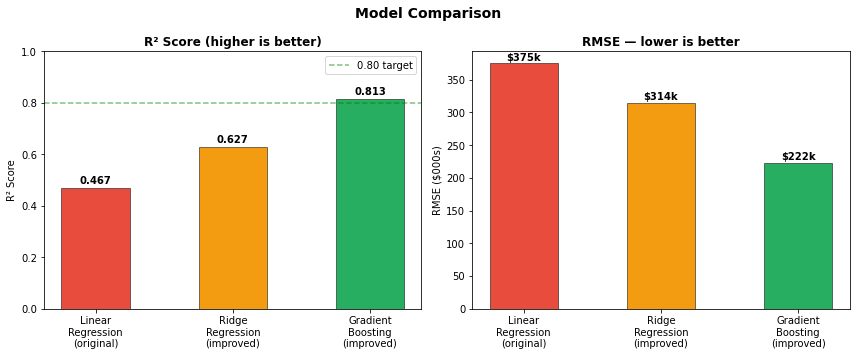

In [35]:
# ─────────────────────────────────────────
# COMPARISON CHART
# Visualise the improvement across all 3 models
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models  = ['Linear\nRegression\n(original)', 'Ridge\nRegression\n(improved)', 'Gradient\nBoosting\n(improved)']
r2s     = [r2_v1,   r2_v2,   r2_v3]
rmses   = [rmse_v1, rmse_v2, rmse_v3]
colors  = ['#e74c3c', '#f39c12', '#27ae60']

# ── R² chart ──
bars = axes[0].bar(models, r2s, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score (higher is better)', fontweight='bold')
axes[0].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='0.80 target')
axes[0].legend()
for bar, val in zip(bars, r2s):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# ── RMSE chart ──
bars2 = axes[1].bar(models, [r/1000 for r in rmses], color=colors, width=0.5,
                    edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('RMSE ($000s)')
axes[1].set_title('RMSE — lower is better', fontweight='bold')
for bar, val in zip(bars2, rmses):
    axes[1].text(bar.get_x() + bar.get_width()/2, val/1000 + 2,
                 f'${val/1000:.0f}k', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

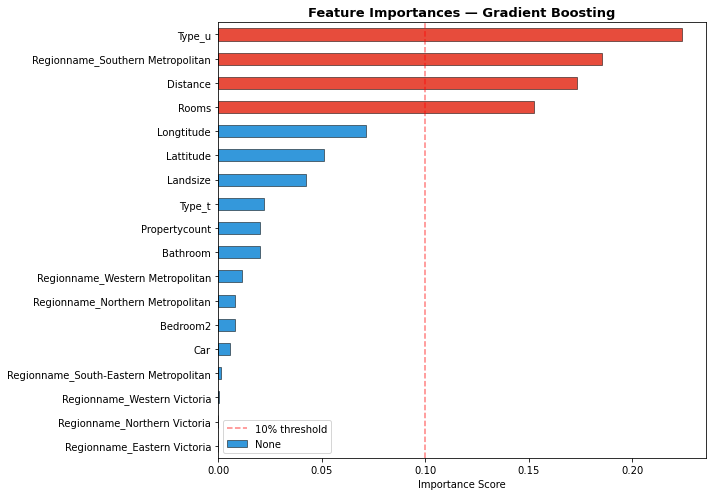

Top 5 most important features:
  Type_u                                        0.224  (22.4%)
  Regionname_Southern Metropolitan              0.186  (18.6%)
  Distance                                      0.173  (17.3%)
  Rooms                                         0.153  (15.3%)
  Longtitude                                    0.071  (7.1%)


In [36]:
# ─────────────────────────────────────────
# FEATURE IMPORTANCE
# Which features actually drove the improvement?
# This answers WHY our model got better
# ─────────────────────────────────────────

feat_imp = pd.Series(
    gb.feature_importances_,
    index=features
).sort_values(ascending=True)  # ascending so longest bar is at top

plt.figure(figsize=(10, 7))

colors = ['#e74c3c' if v > 0.10 else '#3498db' for v in feat_imp.values]

feat_imp.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)

plt.title('Feature Importances — Gradient Boosting', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(x=0.10, color='red', linestyle='--', alpha=0.5, label='10% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print("Top 5 most important features:")
for feat, val in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<45} {val:.3f}  ({val*100:.1f}%)")

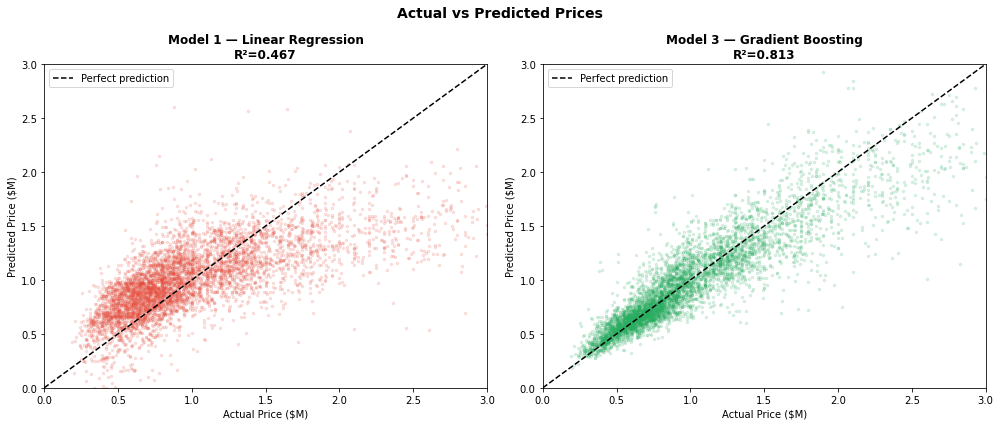

In [37]:
# ─────────────────────────────────────────
# ACTUAL vs PREDICTED
# A perfect model would have all dots on the red line
# The closer dots are to the line, the better our model
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Model 1 (old) ──
axes[0].scatter(y_te1/1e6, p1/1e6,
                alpha=0.15, s=6, color='#e74c3c')
axes[0].plot([0, 3], [0, 3], 'k--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($M)')
axes[0].set_ylabel('Predicted Price ($M)')
axes[0].set_title(f'Model 1 — Linear Regression\nR²={r2_v1:.3f}',
                  fontweight='bold')
axes[0].set_xlim(0, 3)
axes[0].set_ylim(0, 3)
axes[0].legend()

# ── Model 3 (best) ──
axes[1].scatter(y_test_raw/1e6, p3/1e6,
                alpha=0.15, s=6, color='#27ae60')
axes[1].plot([0, 3], [0, 3], 'k--', linewidth=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual Price ($M)')
axes[1].set_ylabel('Predicted Price ($M)')
axes[1].set_title(f'Model 3 — Gradient Boosting\nR²={r2_v3:.3f}',
                  fontweight='bold')
axes[1].set_xlim(0, 3)
axes[1].set_ylim(0, 3)
axes[1].legend()

plt.suptitle('Actual vs Predicted Prices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight', dpi=150)
plt.show()

In [38]:
# ─────────────────────────────────────────
# PREDICT A NEW HOUSE
# Lecture: Testing & Prediction — f̂(x_unknown)
# ─────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

def predict_price(rooms, distance, bathroom, car,
                  lat, lng, bedroom2, landsize,
                  propertycount, prop_type='h',
                  region='Southern Metropolitan'):
    
    # Build a row with all features set to 0 first
    row = {f: 0 for f in features}

    # Fill in the numeric features
    row['Rooms']          = rooms
    row['Distance']       = distance
    row['Bathroom']       = bathroom
    row['Car']            = car
    row['Lattitude']      = lat
    row['Longtitude']     = lng
    row['Bedroom2']       = bedroom2
    row['Landsize']       = landsize
    row['Propertycount']  = propertycount

    # Fill in the categorical features
    if prop_type == 't' and 'Type_t' in row:
        row['Type_t'] = 1
    if prop_type == 'u' and 'Type_u' in row:
        row['Type_u'] = 1

    region_key = f'Regionname_{region}'
    if region_key in row:
        row[region_key] = 1

    X_new    = pd.DataFrame([row])
    log_pred = gb.predict(X_new)[0]
    return np.exp(log_pred)


# ── Example 1: 3 bedroom house, 10km from CBD ──
price = predict_price(
    rooms=3, distance=10, bathroom=1, car=1,
    lat=-37.82, lng=145.0,
    bedroom2=3, landsize=500, propertycount=8000,
    prop_type='h', region='Southern Metropolitan'
)
print(f"3-bed house, 10km from CBD, Southern Metro:")
print(f"  Predicted price: ${price:,.0f}")

# ── Example 2: same house but as a unit ──
price_unit = predict_price(
    rooms=3, distance=10, bathroom=1, car=1,
    lat=-37.82, lng=145.0,
    bedroom2=3, landsize=500, propertycount=8000,
    prop_type='u', region='Southern Metropolitan'
)
print(f"\nSame property but as a unit:")
print(f"  Predicted price: ${price_unit:,.0f}")
print(f"  Difference:      ${price - price_unit:,.0f} less for a unit")

# ── Example 3: further from CBD ──
price_far = predict_price(
    rooms=3, distance=30, bathroom=1, car=1,
    lat=-37.82, lng=145.0,
    bedroom2=3, landsize=500, propertycount=8000,
    prop_type='h', region='Western Metropolitan'
)
print(f"\nSame house but 30km away, Western Metro:")
print(f"  Predicted price: ${price_far:,.0f}")
print(f"  Difference:      ${price - price_far:,.0f} less for being further out")

3-bed house, 10km from CBD, Southern Metro:
  Predicted price: $1,431,273

Same property but as a unit:
  Predicted price: $921,576
  Difference:      $509,696 less for a unit

Same house but 30km away, Western Metro:
  Predicted price: $470,022
  Difference:      $961,251 less for being further out
